# Neural Network for CIFAR-10 classification


In this hometask you'll implement and train neural networks for classification of images from the CIFAR-10 dataset.


CIFAR-10 is a dataset of small **color** images from 10 object classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. Each image has size **32×32×3**. This makes the task harder than MNIST, because now the images are colored and the objects are much more visually diverse.


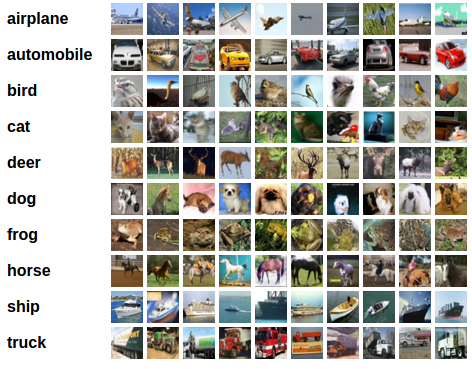

We will also visualize a few CIFAR-10 images after loading the dataset.


## Loading data


The cell below downloads CIFAR-10 using `torchvision`.


In [1]:
import torchvision
from torchvision import transforms

train_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True
)
test_dataset_raw = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True
)


/Users/armantsaturian/Developer/2026/nebius_course/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


After this, you'll have the CIFAR-10 training and testing splits downloaded into the `./data` directory.


Let's import NumPy, Pandas and look at our data:


In [2]:
import numpy as np
import pandas as pd

In [3]:
class_names = train_dataset_raw.classes

train_images = train_dataset_raw.data
test_images = test_dataset_raw.data
train_labels = np.array(train_dataset_raw.targets)
test_labels = np.array(test_dataset_raw.targets)

# flatten images so that each object is represented as a vector
train_flat = train_images.reshape(len(train_images), -1)
test_flat = test_images.reshape(len(test_images), -1)

train_data = pd.DataFrame(train_flat)
train_data['label'] = train_labels

test_data = pd.DataFrame(test_flat)
test_data['label'] = test_labels

train_data.head()


,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,59,62,63,43,46,45,50,48,43,68,...,216,184,140,151,118,84,123,92,72,6
1,154,177,187,126,137,136,105,104,95,102,...,143,133,139,143,134,142,143,133,144,9
2,255,255,255,253,253,253,253,253,253,253,...,78,85,83,79,85,83,80,86,84,9
3,28,25,10,37,34,19,38,35,20,42,...,54,47,28,63,56,37,72,65,46,4
4,170,180,198,168,178,196,177,185,203,183,...,75,79,82,71,75,78,73,77,80,1


In this table, each image is represented as a vector of size **32×32×3 = 3072**, where each feature corresponds to one pixel channel (Red, Green or Blue) value. Pixel values are in the range **[0, 255]**.

Column `label` is the target variable representing the image class. The class mapping is:

```python
{idx: name for idx, name in enumerate(class_names)}
```


Let's visualize the first image:


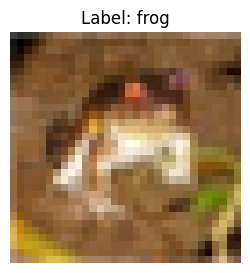

In [4]:
import matplotlib.pyplot as plt

# you can change the index and visualize different images
idx = 0
img = train_images[idx]
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f'Label: {class_names[train_labels[idx]]}')
plt.axis('off');

Let's also load test data:


In [7]:
# test_data has already been created above
test_data.head()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,158,112,49,159,111,47,165,116,51,166,...,24,77,124,34,84,129,21,67,110,3
1,235,235,235,231,231,231,232,232,232,232,...,168,183,178,180,195,191,186,200,199,8
2,158,190,222,158,187,218,139,166,194,132,...,5,6,8,4,5,3,7,8,7,8
3,155,156,149,167,176,187,176,179,193,190,...,60,63,50,64,65,52,73,68,50,0
4,65,68,50,70,81,64,48,64,46,30,...,143,179,136,154,185,146,128,156,117,6


## Task 1. Binary classification with NNs


In this first task you'll define and train a neural network for **binary classification** of CIFAR-10 images.

As we have 10 classes in the full dataset, we'll first extract parts of the data containing only two classes.

We will solve two tasks: classification of classes that usually look quite different (**airplane** vs **ship**) and classification of classes that are much easier to confuse (**cat** vs **dog**). It is interesting to see how these tasks differ in difficulty and whether different neural network architectures or hyperparameters are optimal for them.


So let's extract data for airplane/ship classification and for cat/dog classification:


In [8]:
# frog / ship classification
labels_to_train = [class_names.index('frog'), class_names.index('ship')]
train_data_frog_ship = train_data[train_data['label'].isin(labels_to_train)].copy()
test_data_frog_ship = test_data[test_data['label'].isin(labels_to_train)].copy()

# convert labels to 0/1 for binary classification
train_data_frog_ship['label'] = (train_data_frog_ship['label'] == class_names.index('ship')).astype(int)
test_data_frog_ship['label'] = (test_data_frog_ship['label'] == class_names.index('ship')).astype(int)

# divide data into features and target variable
X_train_frog_ship = train_data_frog_ship.drop(columns=['label'])
y_train_frog_ship = train_data_frog_ship['label']
X_test_frog_ship = test_data_frog_ship.drop(columns=['label'])
y_test_frog_ship = test_data_frog_ship['label']


In [143]:
from sklearn.model_selection import train_test_split

# cat / dog classification
labels_to_train = [class_names.index('cat'), class_names.index('dog')]
train_data_cat_dog = train_data[train_data['label'].isin(labels_to_train)].copy()
test_data_cat_dog = test_data[test_data['label'].isin(labels_to_train)].copy()

# convert labels to 0/1 for binary classification
train_data_cat_dog['label'] = (train_data_cat_dog['label'] == class_names.index('dog')).astype(int)
test_data_cat_dog['label'] = (test_data_cat_dog['label'] == class_names.index('dog')).astype(int)

# split training data into train/val (90/10)
X_tr_cd, X_val_cd, y_tr_cd, y_val_cd = train_test_split(
    train_data_cat_dog.drop(columns="label").values,
    train_data_cat_dog["label"].values,
    test_size=0.1, random_state=42, stratify=train_data_cat_dog["label"].values
)

X_test_cat_dog = test_data_cat_dog.drop(columns=['label']).values
y_test_cat_dog = test_data_cat_dog['label'].values

In [43]:
train_data_cat_dog

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
9,125,125,116,110,101,91,102,90,83,106,...,143,117,82,143,116,84,144,116,86,0
17,110,104,97,142,135,118,151,146,120,133,...,45,48,60,47,46,60,51,48,62,0
21,252,8,42,249,15,42,250,8,39,251,...,250,78,113,250,74,109,251,58,88,0
26,131,81,32,124,76,27,116,70,20,124,...,140,104,69,156,114,73,164,118,73,0
27,45,20,19,42,21,18,35,17,13,33,...,77,68,53,66,75,29,83,99,31,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49979,4,4,4,4,4,4,5,5,5,0,...,12,13,11,11,11,11,3,3,3,0
49980,110,115,109,90,122,104,82,117,95,88,...,47,92,73,39,81,65,67,92,81,1
49982,41,41,41,39,39,37,39,39,36,41,...,80,56,44,82,56,44,85,59,45,0
49983,41,29,21,43,28,20,43,26,16,45,...,248,216,212,252,225,222,242,208,205,0


### Task 1.1. Write a neural network for binary classification


For now, write any architecture that would consume a flattened CIFAR-10 image and output the probability of class 1. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


In [77]:
import torch.nn as nn
import torch

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # define layers and activation function that your model will have
        hidden_size = 128
        self.fc1 = nn.Linear(32 * 32 * 3, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)

    def forward(self, x):

        # define a flow of input through your layers
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


And create a network:


In [78]:
net = Net()

### Task 1.2. Define a train function.


You can borrow the code from our practical session.

It might also be beneficial to see how training loss evolves during training, this will help you do experiments later. You can either save average of losses on batches per epoch into array and return it as output of the `train` function, so you can then visualize it using [matplotlib.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html). Or you can add plotting average of losses on batches per epoch inside the `train` function. In this case you might also need using a function to clear output of the cell, so you can draw new plot after each epoch. You can find how to do it [here](https://stackoverflow.com/questions/24816237/ipython-notebook-clear-cell-output-in-code)


In [182]:
import tqdm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
import copy

def train(model, train_loader, criterion, optimizer, num_epoch, val_loader=None, patience=None, silent=False):
    train_losses = []
    val_losses = []
    val_accs = []

    # early stopping state
    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_state = None
    wait = 0
    best_epoch = None

    for epoch in range(num_epoch):
        model.train()
        avg_loss = 0.0
        for i, (x, y) in enumerate(train_loader, 1):
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred.squeeze(1), y)
            loss.backward()
            optimizer.step()
            avg_loss += (loss.item() - avg_loss) / i

        train_losses.append(avg_loss)

        # validation
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for j, (xv, yv) in enumerate(val_loader, 1):
                    pred_v = model(xv)
                    loss_v = criterion(pred_v.squeeze(1), yv)
                    val_loss += (loss_v.item() - val_loss) / j
                    correct += ((pred_v.squeeze(1) > 0) == yv).sum().item()
                    total += yv.size(0)
            val_losses.append(val_loss)
            val_accs.append(correct / total)

            # early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_accs[-1]
                best_epoch = epoch + 1
                best_state = copy.deepcopy(model.state_dict())
                wait = 0
            else:
                wait += 1
                if patience is not None and wait >= patience:
                    if not silent:
                        print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                    break

        if not silent:
            clear_output(wait=True)
            plt.figure()
            plt.plot(range(1, len(train_losses) + 1), train_losses, label="train")
            if val_losses:
                plt.plot(range(1, len(val_losses) + 1), val_losses, label="val")
                if best_epoch is not None:
                    plt.plot(best_epoch, best_val_loss, "*", color="red", markersize=14, zorder=5,
                             label=f"best val (ep {best_epoch}, acc {best_val_acc:.4f})")
            plt.xlabel("Epoch")
            plt.ylabel("Avg Loss")
            plt.title("Training Loss")
            plt.legend()
            plt.show()

    # restore best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)

    # attach history to model
    model._history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
    }

    return model

And let's define loss function, optimizer, dataloader and train our network. For now, use `train_data_frog_ship` to pass to the dataloader.


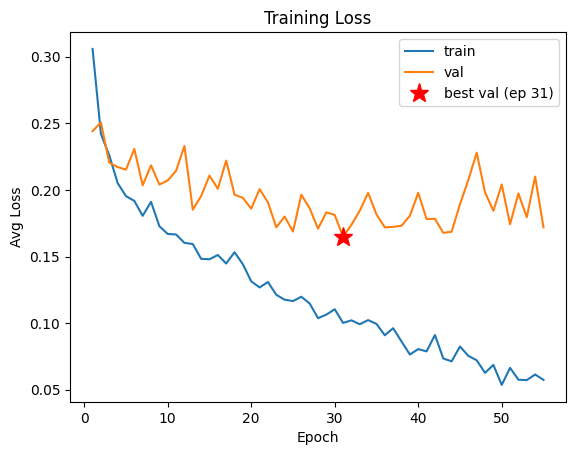

Early stopping at epoch 56 (no improvement for 25 epochs)


In [80]:
# loss function
criterion = nn.BCEWithLogitsLoss()
# optimizer
optimizer = torch.optim.Adam(net.parameters())
i
# split training data into train/val
X_tr, X_val, y_tr, y_val = train_test_split(
    train_data_frog_ship.drop(columns="label").values,
    train_data_frog_ship["label"].values,
    test_size=0.1, random_state=42, stratify=train_data_frog_ship["label"].values
)

# train dataloader
train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_tr / 255.0, dtype=torch.float32),
    torch.tensor(y_tr, dtype=torch.float32)
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# val dataloader
val_dataset = torch.utils.data.TensorDataset(
    torch.tensor(X_val / 255.0, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

# run training
net = train(net, train_loader, criterion, optimizer, 100, val_loader=val_loader, patience=25)


### Task 1.3. Write a code for model evaluation


After we train our neural network, we'll need to evaluate it on test data and compute accuracy metric. Let's now define the function for it. Your task is to fill the gaps in the code below


In [175]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []
    
    model.eval()
    for X_batch, y_batch in loader:

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = model(X_batch)

            # calculate loss function
            loss = criterion(y_pred.squeeze(1), y_batch)
            losses.append(loss.item())


        # convert outputs of your network into class number
        y_pred = (y_pred.squeeze(1) > 0).float()

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = sum(p == y for p, y in zip(y_pred_list, y_true_list)) / len(y_true_list)
    return np.mean(losses), accuracy


And let's evaluate our trained network on test data. Use `test_data_frog_ship` for testing.


In [83]:
# dataloader
test_dataset = torch.utils.data.TensorDataset(
      torch.tensor(test_data_frog_ship.drop(columns="label").values / 255.0, dtype=torch.float32),
      torch.tensor(test_data_frog_ship["label"].values, dtype=torch.float32)
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

evaluate(net, test_loader, criterion)


(np.float64(0.19256569306196678), tensor([0.9450]))

### Task 1.4. Train the neural network to classify airplane/ship images


Now you have a network that can be trained and evaluated on binary classification data. Your task is to improve it so that your neural network can achieve **>0.94 accuracy** on the test part.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 64-256 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer?
- Play with number of layers, number of neurons, and different activation functions
- Try different training **hyperparameters**: learning rate, number of epochs, optimizer type, batch size

After you've done experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** (number of layers) and **width** (number of neurons in a layer).
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.


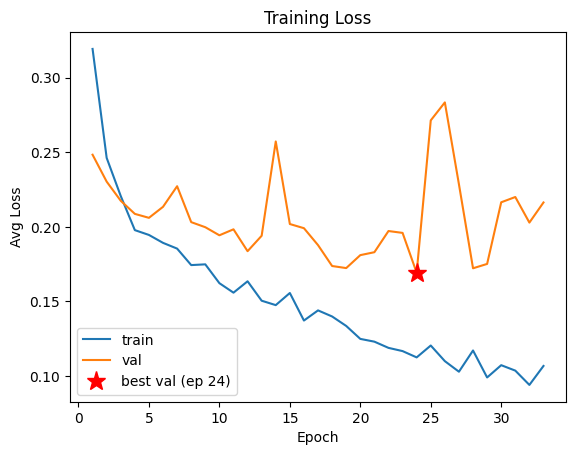

Early stopping at epoch 34 (no improvement for 10 epochs)
    test acc: 0.9280


,hidden,params,test_loss,test_acc
architecture,,,,
1h-64,[64],196737,0.173345,0.943
1h-256,[256],786945,0.163874,0.9425
2h-64-128,"[64, 128]",205121,0.181722,0.9345
1h-128,[128],393473,0.192849,0.9335
2h-256-128,"[256, 128]",819713,0.185575,0.9335
2h-128-64,"[128, 64]",401665,0.194221,0.933
2h-128-256,"[128, 256]",426625,0.240402,0.928
2h-64-256,"[64, 256]",213569,0.223259,0.917
2h-256-64,"[256, 64]",803201,0.40652,0.8915


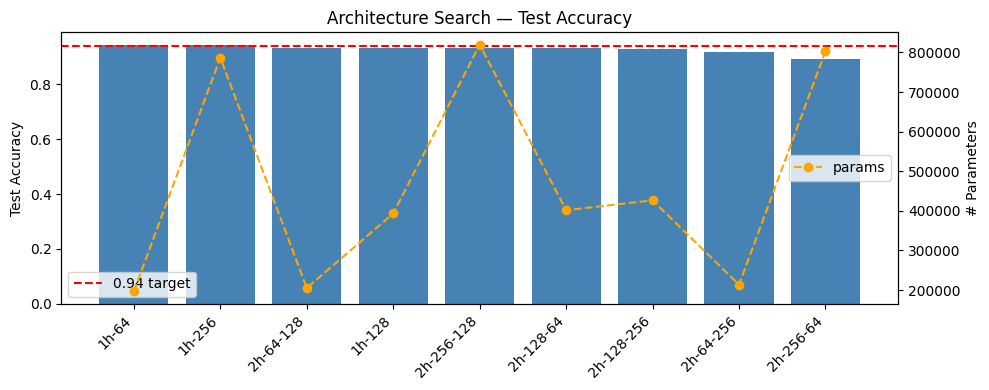

In [127]:
# ── Experiment 1: Architecture search ──

architectures = {
    "1h-64":        [64],
    "1h-128":       [128],
    "1h-256":       [256],
    "2h-128-64":    [128, 64],
    "2h-64-128":    [64, 128],
    "2h-256-64":    [256, 64],
    "2h-64-256":    [64, 256],
    "2h-256-128":   [256, 128],
    "2h-128-256":   [128, 256],
}

class FlexNet(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()
        layers = []
        in_dim = 32 * 32 * 3
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

EPOCHS = 60
PATIENCE = 10

arch_results = {}

for name, hidden in architectures.items():
    print(f"Training {name} ...")
    model = FlexNet(hidden)
    print(f"    params: {model.num_params():,}")

    opt = torch.optim.Adam(model.parameters())
    crit = nn.BCEWithLogitsLoss()

    model = train(model, train_loader, crit, opt, EPOCHS, val_loader=val_loader, patience=PATIENCE)

    test_loss, test_acc = evaluate(model, test_loader, crit)
    test_acc = float(test_acc)
    print(f"    test acc: {test_acc:.4f}")

    arch_results[name] = {
        "hidden": hidden,
        "params": model.num_params(),
        "test_loss": test_loss,
        "test_acc": test_acc,
    }


,hidden,params,test_loss,test_acc
architecture,,,,
1h-64,[64],196737,0.173345,0.943
1h-256,[256],786945,0.163874,0.9425
2h-64-128,"[64, 128]",205121,0.181722,0.9345
1h-128,[128],393473,0.192849,0.9335
2h-256-128,"[256, 128]",819713,0.185575,0.9335
2h-128-64,"[128, 64]",401665,0.194221,0.933
2h-128-256,"[128, 256]",426625,0.240402,0.928
2h-64-256,"[64, 256]",213569,0.223259,0.917
2h-256-64,"[256, 64]",803201,0.40652,0.8915


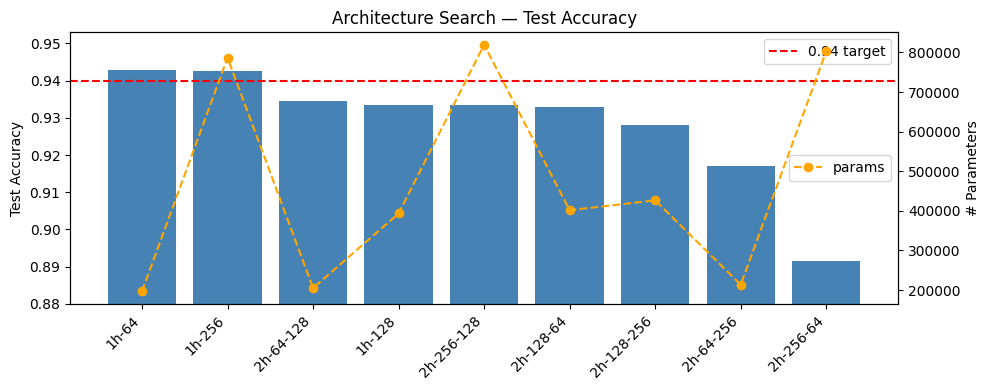

In [129]:
# ── Experiment 1: Summary ──
import pandas as pd

df_arch = pd.DataFrame(arch_results).T
df_arch = df_arch.sort_values("test_acc", ascending=False)
df_arch["params"] = df_arch["params"].astype(int)
df_arch.index.name = "architecture"
display(df_arch)

# ── Bar chart ──
fig, ax1 = plt.subplots(figsize=(10, 4))
x = range(len(df_arch))
ax1.bar(x, df_arch["test_acc"], color="steelblue")
ax1.axhline(0.94, color="red", linestyle="--", label="0.94 target")
ax1.set_xticks(x)
ax1.set_xticklabels(df_arch.index, rotation=45, ha="right")
ax1.set_ylabel("Test Accuracy")
ax1.set_ylim(0.88, df_arch["test_acc"].max() + 0.01)
ax1.set_title("Architecture Search — Test Accuracy")
ax1.legend()

ax2 = ax1.twinx()
ax2.plot(x, df_arch["params"], "o--", color="orange", label="params")
ax2.set_ylabel("# Parameters")
ax2.legend(loc="center right")

plt.tight_layout()
plt.show()


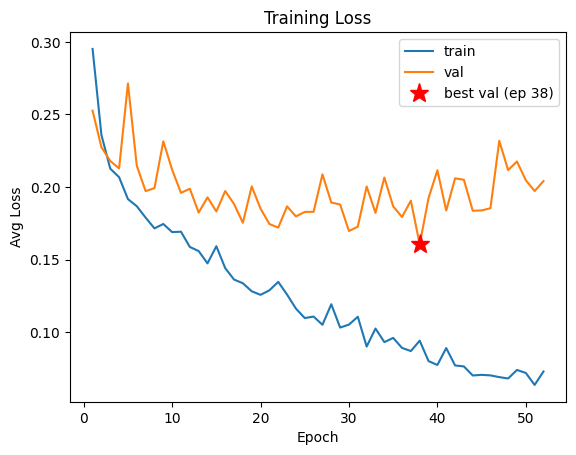

Early stopping at epoch 53 (no improvement for 15 epochs)
    test acc: 0.9385


In [130]:
# ── Experiment 2: Learning rate search ──

lr_archs = {
    "1h-64":     [64],
    "1h-256":    [256],
    "2h-64-128": [64, 128],
}

learning_rates = [1e-4, 3e-4, 1e-3]

LR_EPOCHS = 120
LR_PATIENCE = 15

lr_results = {}

for arch_name, hidden in lr_archs.items():
    for lr in learning_rates:
        tag = f"{arch_name}_lr{lr}"
        print(f"Training {tag} ...")
        model = FlexNet(hidden)

        opt = torch.optim.Adam(model.parameters(), lr=lr)
        crit = nn.BCEWithLogitsLoss()

        model = train(model, train_loader, crit, opt, LR_EPOCHS, val_loader=val_loader, patience=LR_PATIENCE)

        test_loss, test_acc = evaluate(model, test_loader, crit)
        test_acc = float(test_acc)
        print(f"    test acc: {test_acc:.4f}")

        lr_results[tag] = {
            "arch": arch_name,
            "lr": lr,
            "params": model.num_params(),
            "test_loss": test_loss,
            "test_acc": test_acc,
        }


,arch,lr,params,test_loss,test_acc
experiment,,,,,
1h-64_lr0.0001,1h-64,0.0001,196737,0.158075,0.946
1h-256_lr0.0001,1h-256,0.0001,786945,0.166823,0.946
1h-256_lr0.001,1h-256,0.001,786945,0.184452,0.942
1h-64_lr0.0003,1h-64,0.0003,196737,0.174679,0.941
2h-64-128_lr0.0003,2h-64-128,0.0003,205121,0.172282,0.941
1h-64_lr0.001,1h-64,0.001,196737,0.183754,0.94
2h-64-128_lr0.001,2h-64-128,0.001,205121,0.206625,0.9385
2h-64-128_lr0.0001,2h-64-128,0.0001,205121,0.20228,0.9335
1h-256_lr0.0003,1h-256,0.0003,786945,0.199646,0.9325


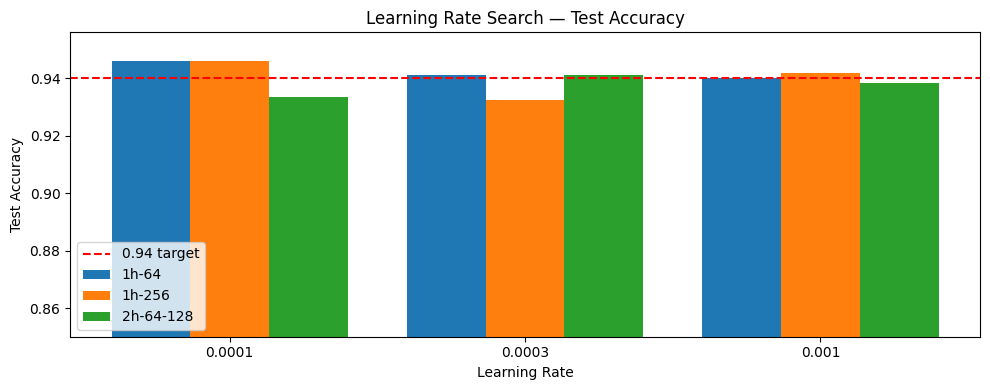

In [131]:
# ── Experiment 2: Summary ──

df_lr = pd.DataFrame(lr_results).T
df_lr = df_lr.sort_values("test_acc", ascending=False)
df_lr.index.name = "experiment"
display(df_lr)

# ── Grouped bar chart: accuracy by lr, grouped by architecture ──
fig, ax = plt.subplots(figsize=(10, 4))

arch_names = list(lr_archs.keys())
n_arch = len(arch_names)
n_lr = len(learning_rates)
bar_w = 0.8 / n_arch

for i, arch_name in enumerate(arch_names):
    accs = [lr_results[f"{arch_name}_lr{lr}"]["test_acc"] for lr in learning_rates]
    positions = [j + i * bar_w for j in range(n_lr)]
    ax.bar(positions, accs, width=bar_w, label=arch_name)

ax.axhline(0.94, color="red", linestyle="--", label="0.94 target")
ax.set_xticks([j + bar_w * (n_arch - 1) / 2 for j in range(n_lr)])
ax.set_xticklabels([str(lr) for lr in learning_rates])
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0.85, df_lr["test_acc"].max() + 0.01)
ax.set_title("Learning Rate Search — Test Accuracy")
ax.legend()
plt.tight_layout()
plt.show()


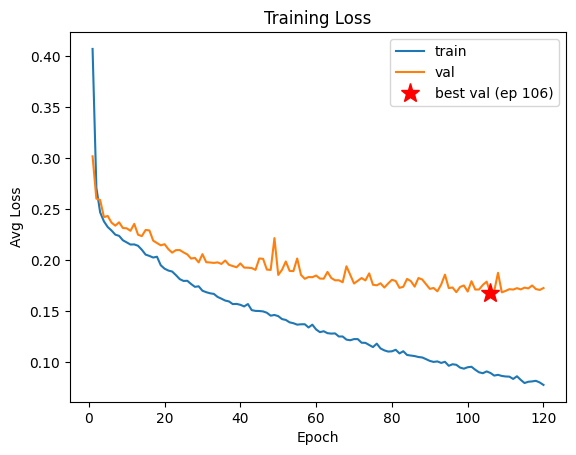

Incorrect: 107 / 2000 (5.3%)
Correct:   1893 / 2000 (94.7%)


In [132]:
# ── Error analysis: 1h-64 @ lr=1e-4 ──

# retrain this specific config (model was overwritten in the loop)
err_model = FlexNet([64])
err_opt = torch.optim.Adam(err_model.parameters(), lr=1e-4)
err_crit = nn.BCEWithLogitsLoss()
err_model = train(err_model, train_loader, err_crit, err_opt, 120, val_loader=val_loader, patience=15)

# get predictions on test set
err_model.eval()
all_preds = []
all_labels = []
all_inputs = []

with torch.no_grad():
    for xb, yb in test_loader:
        logits = err_model(xb)
        preds = (logits.squeeze(1) > 0.0).float()  # threshold at 0 for logits
        all_preds.append(preds)
        all_labels.append(yb)
        all_inputs.append(xb)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_inputs = torch.cat(all_inputs)

incorrect_mask = all_preds != all_labels
n_incorrect = incorrect_mask.sum().item()
n_total = len(all_labels)
print(f"Incorrect: {n_incorrect} / {n_total} ({n_incorrect/n_total*100:.1f}%)")
print(f"Correct:   {n_total - n_incorrect} / {n_total} ({(n_total - n_incorrect)/n_total*100:.1f}%)")


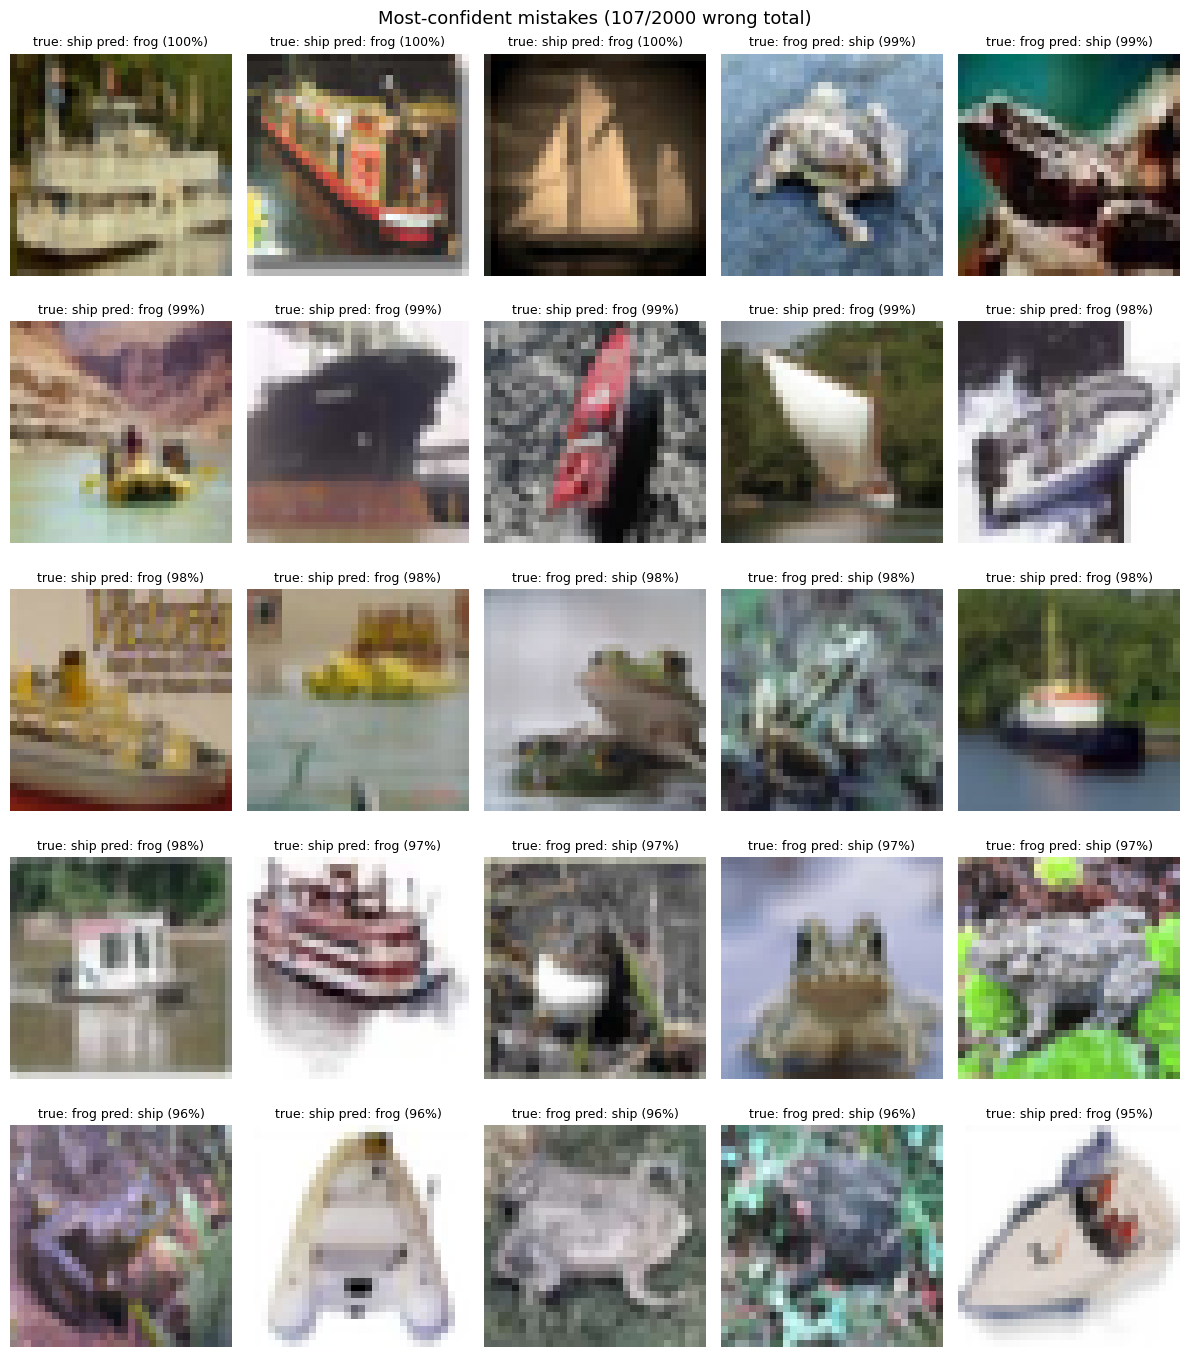

In [142]:
def show_predictions(model, loader, label_names, n=25, mode="worst_mistakes"):
    """
    Show a grid of predictions.
    mode:
      "worst_mistakes"  — incorrect, sorted by highest confidence (most confident errors)
      "least_confident" — correct, sorted by lowest confidence (barely got it right)
    """
    model.eval()
    all_logits, all_labels, all_inputs = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            all_logits.append(model(xb).squeeze(1))
            all_labels.append(yb)
            all_inputs.append(xb)

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    all_inputs = torch.cat(all_inputs)

    all_probs = torch.sigmoid(all_logits)
    all_preds = (all_logits > 0.0).float()
    confidence = (all_probs - 0.5).abs()

    if mode == "worst_mistakes":
        mask = all_preds != all_labels
        pool = torch.where(mask)[0]
        order = confidence[pool].argsort(descending=True)
        title_prefix = "Most-confident mistakes"
    elif mode == "least_confident":
        mask = all_preds == all_labels
        pool = torch.where(mask)[0]
        order = confidence[pool].argsort(descending=False)
        title_prefix = "Correct but least confident"
    else:
        raise ValueError(f"Unknown mode: {mode}")

    top_n = pool[order[:n]]
    n_show = len(top_n)
    cols = 5
    rows = (n_show + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(2.4 * cols, 2.8 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax_i, idx in enumerate(top_n):
        ax = axes[ax_i // cols][ax_i % cols]
        img = (all_inputs[idx].numpy() * 255.0).reshape(32, 32, 3).astype("uint8")
        true_label = int(all_labels[idx].item())
        pred_label = int(all_preds[idx].item())
        prob = all_probs[idx].item()
        conf_pct = prob if pred_label == 1 else 1 - prob

        ax.imshow(img)
        ax.set_title(f"true: {label_names[true_label]} pred: {label_names[pred_label]} ({conf_pct:.0%})", fontsize=9)
        ax.axis("off")

    for ax_i in range(n_show, rows * cols):
        axes[ax_i // cols][ax_i % cols].axis("off")

    n_wrong = (all_preds != all_labels).sum().item()
    fig.suptitle(f"{title_prefix} ({n_wrong}/{len(all_labels)} wrong total)", fontsize=13)
    plt.tight_layout()
    plt.show()

show_predictions(err_model, test_loader, ["frog", "ship"], mode="worst_mistakes")
# show_predictions(err_model, test_loader, ["frog", "ship"], mode="least_confident")


# Experiments

#### 1. Architecture Search
- Experiment with different depths with dirfferent setups showed still the simplesd 1 hidden layer with 64 neurons to be the best. Having lowest number of params and best test accuracy of 0.943. Why? Hard to answer, because the first intuition is that deeper net should achieve better results, but it's possible that for this task one hidden layer is complex enough and achieves better generalisation, while deeper networks result in overfittng. But overall they all achive same accuracy without significant stat difference to claim one better thatn the other.
- Learning rate experiments with Adam resulted in best models achieving 0.946 test acc at LR=0.0001. When reviewing images on whicih the model is most wrong in test - it's not clear what's really going wrong. VIsually the labels are correct and ther're not many hard example for human eye.

### Task 1.5. Train the neural network to classify cat/dog images


Now that you have optimized your network for airplane/ship classification, try to solve cat/dog classification. This task is harder, because cats and dogs can have similar colors, shapes, and poses. Again, your neural network should achieve **>0.64 accuracy** on the test part.

First, try training the same network that you've optimized for the airplane/ship task. Can it successfully solve cat/dog classification? If not, experiment with model architecture and hyperparameters again.

In this task you might also need to use BatchNorm and Dropout layers. Here's documentations:
- BatchNorm: https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html
- Dropout: https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html

**Note:** Both BatchNorm and Dropout layers behave differently on training and inference. Don't forget to set `model.train()` and `model.eval()` before training/evaluation phases.

Below there's also theory block on BatchNorm.

After you've done experimenting, describe your findings. Again, try to answer the following questions:
- How large should the neural network be to solve the task successfully? Is that different from what you had on the airplane/ship task?
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same loss value change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.

Here is also an example of visual appearance of these classes — you may want to inspect several training images manually to understand why the task is difficult.


In [164]:
# cat/dog dataloaders
train_dataset_cd = torch.utils.data.TensorDataset(
    torch.tensor(X_tr_cd / 255.0, dtype=torch.float32),
    torch.tensor(y_tr_cd, dtype=torch.float32)
)
train_loader_cd = torch.utils.data.DataLoader(train_dataset_cd, batch_size=64, shuffle=True)

val_dataset_cd = torch.utils.data.TensorDataset(
    torch.tensor(X_val_cd / 255.0, dtype=torch.float32),
    torch.tensor(y_val_cd, dtype=torch.float32)
)
val_loader_cd = torch.utils.data.DataLoader(val_dataset_cd, batch_size=64, shuffle=False)

test_dataset_cd = torch.utils.data.TensorDataset(
    torch.tensor(X_test_cat_dog / 255.0, dtype=torch.float32),
    torch.tensor(y_test_cat_dog, dtype=torch.float32)
)
test_loader_cd = torch.utils.data.DataLoader(test_dataset_cd, batch_size=64, shuffle=False)

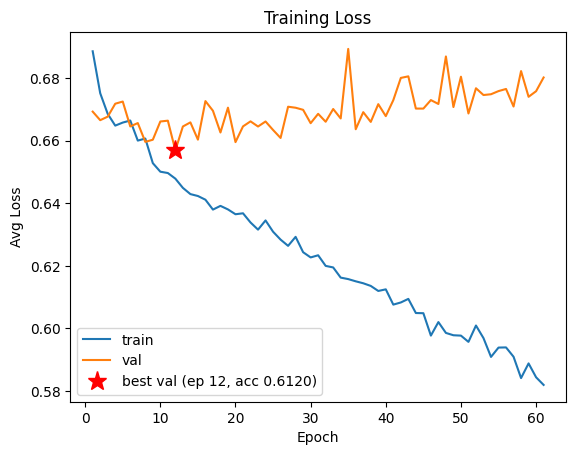

Early stopping at epoch 62 (no improvement for 50 epochs)
test acc: 0.5950000286102295


In [165]:
# 1 hidden 64 neurons
net_cat_dog = FlexNet([64])
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(net_cat_dog.parameters())
net_cat_dog = train(net_cat_dog, train_loader_cd, criterion, optimizer, 100, val_loader=val_loader_cd, patience=50)
test_loss, test_acc = evaluate(net_cat_dog, test_loader_cd, criterion)
print("test acc:", test_acc.item())

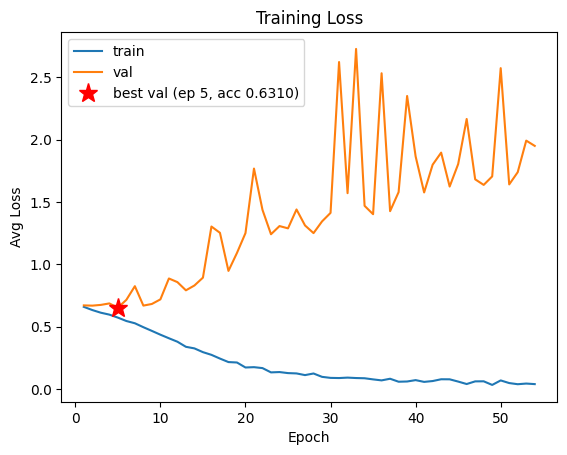

Early stopping at epoch 55 (no improvement for 50 epochs)
test acc: 0.621999979019165


In [177]:
# batch norm two layers 128 64
net_cat_dog_batchnorm_128_64 = nn.Sequential(
      nn.Linear(32 * 32 * 3, 128),
      nn.BatchNorm1d(128),
      nn.ReLU(),
      nn.Linear(128, 64),
      nn.BatchNorm1d(64),
      nn.ReLU(),
      nn.Linear(64, 1),
  )
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(net_cat_dog_batchnorm_128_64.parameters())
net_cat_dog_batchnorm_128_64 = train(net_cat_dog_batchnorm_128_64, train_loader_cd, criterion, optimizer, 100, val_loader=val_loader_cd, patience=50)
test_loss, test_acc = evaluate(net_cat_dog_batchnorm_128_64, test_loader_cd, criterion)
print("test acc:", test_acc.item())

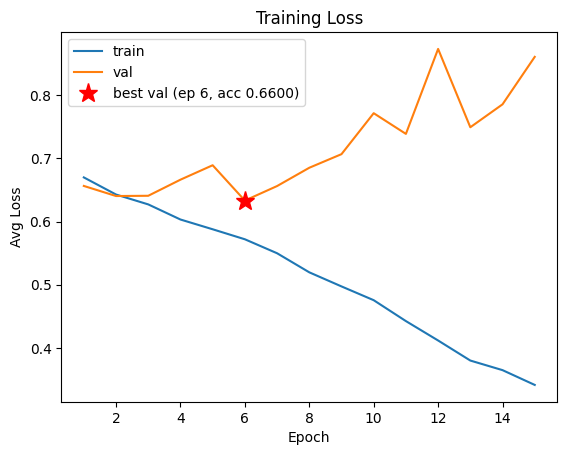

Early stopping at epoch 16 (no improvement for 10 epochs)
test acc: 0.6420000195503235


In [ ]:
# batch norm two layers 128 64
net_cat_dog_batchnorm_256_128_64 = nn.Sequential(
      nn.Linear(32 * 32 * 3, 512),
      nn.BatchNorm1d(512),
      nn.ReLU(),
    #   nn.Dropout(0.3),
      nn.Linear(512, 256),
      nn.BatchNorm1d(256),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(256, 128),
      nn.BatchNorm1d(128),
      nn.ReLU(),
      nn.Dropout(0.3),
      nn.Linear(128, 1),
  )
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(net_cat_dog_batchnorm_256_128_64.parameters(), lr=3e-4)
net_cat_dog_batchnorm_256_128_64 = train(net_cat_dog_batchnorm_256_128_64, train_loader_cd, criterion, optimizer, 100, val_loader=val_loader_cd, patience=10)
test_loss, test_acc = evaluate(net_cat_dog_batchnorm_256_128_64, test_loader_cd, criterion)
print("test acc:", test_acc.item())

In [183]:
def build_bn_model(hidden_sizes, dropout=0.0):
    layers = []
    in_dim = 32 * 32 * 3
    for h in hidden_sizes:
        layers.append(nn.Linear(in_dim, h))
        layers.append(nn.BatchNorm1d(h))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        in_dim = h
    layers.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*layers)

experiments = {
    "512-256-128_lr3e-4":      {"h": [512, 256, 128], "lr": 3e-4, "drop": 0.0, "wd": 0.0},
    "512-256-128_lr1e-3":      {"h": [512, 256, 128], "lr": 1e-3, "drop": 0.0, "wd": 0.0},
    "512-256-128_lr1e-4":      {"h": [512, 256, 128], "lr": 1e-4, "drop": 0.0, "wd": 0.0},
    "1024-512-128_lr3e-4":     {"h": [1024, 512, 128], "lr": 3e-4, "drop": 0.0, "wd": 0.0},
    "1024-512-128_lr1e-3":     {"h": [1024, 512, 128], "lr": 1e-3, "drop": 0.0, "wd": 0.0},
    "1024-256_lr3e-4":         {"h": [1024, 256], "lr": 3e-4, "drop": 0.0, "wd": 0.0},
    "1024-256_lr1e-3":         {"h": [1024, 256], "lr": 1e-3, "drop": 0.0, "wd": 0.0},
    "512-256-128_lr3e-4_drop": {"h": [512, 256, 128], "lr": 3e-4, "drop": 0.3, "wd": 0.0},
    "512-256-128_lr1e-3_drop": {"h": [512, 256, 128], "lr": 1e-3, "drop": 0.3, "wd": 0.0},
    "512-256-128_lr3e-4_wd":   {"h": [512, 256, 128], "lr": 3e-4, "drop": 0.0, "wd": 1e-4},
    "512-256-128_lr1e-3_wd":   {"h": [512, 256, 128], "lr": 1e-3, "drop": 0.0, "wd": 1e-4},
    "1024-512-128_lr3e-4_wd":  {"h": [1024, 512, 128], "lr": 3e-4, "drop": 0.0, "wd": 1e-4},
}

EPOCHS = 120
PATIENCE = 25
cd_results = {}

for name, cfg in experiments.items():
    print(f"Training {name} ...")
    model = build_bn_model(cfg["h"], cfg["drop"])
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])
    crit = nn.BCEWithLogitsLoss()
    model = train(model, train_loader_cd, crit, opt, EPOCHS, val_loader=val_loader_cd, patience=PATIENCE, silent=True)
    test_loss, test_acc = evaluate(model, test_loader_cd, crit)
    test_acc = float(test_acc)
    params = sum(p.numel() for p in model.parameters())
    cd_results[name] = {
        "test_acc": test_acc,
        "test_loss": test_loss,
        "params": params,
        "history": model._history,
        **cfg,
    }
    print(f"  test_acc={test_acc:.4f}, params={params:,}")

print("\nAll experiments done!")

Training 512-256-128_lr3e-4 ...
  test_acc=0.6230, params=1,739,521
Training 512-256-128_lr1e-3 ...
  test_acc=0.6395, params=1,739,521
Training 512-256-128_lr1e-4 ...
  test_acc=0.6515, params=1,739,521
Training 1024-512-128_lr3e-4 ...
  test_acc=0.6220, params=3,740,673
Training 1024-512-128_lr1e-3 ...
  test_acc=0.6375, params=3,740,673
Training 1024-256_lr3e-4 ...
  test_acc=0.6385, params=3,411,969
Training 1024-256_lr1e-3 ...
  test_acc=0.6360, params=3,411,969
Training 512-256-128_lr3e-4_drop ...
  test_acc=0.6265, params=1,739,521
Training 512-256-128_lr1e-3_drop ...
  test_acc=0.6290, params=1,739,521
Training 512-256-128_lr3e-4_wd ...
  test_acc=0.6205, params=1,739,521
Training 512-256-128_lr1e-3_wd ...
  test_acc=0.6135, params=1,739,521
Training 1024-512-128_lr3e-4_wd ...
  test_acc=0.6220, params=3,740,673

All experiments done!


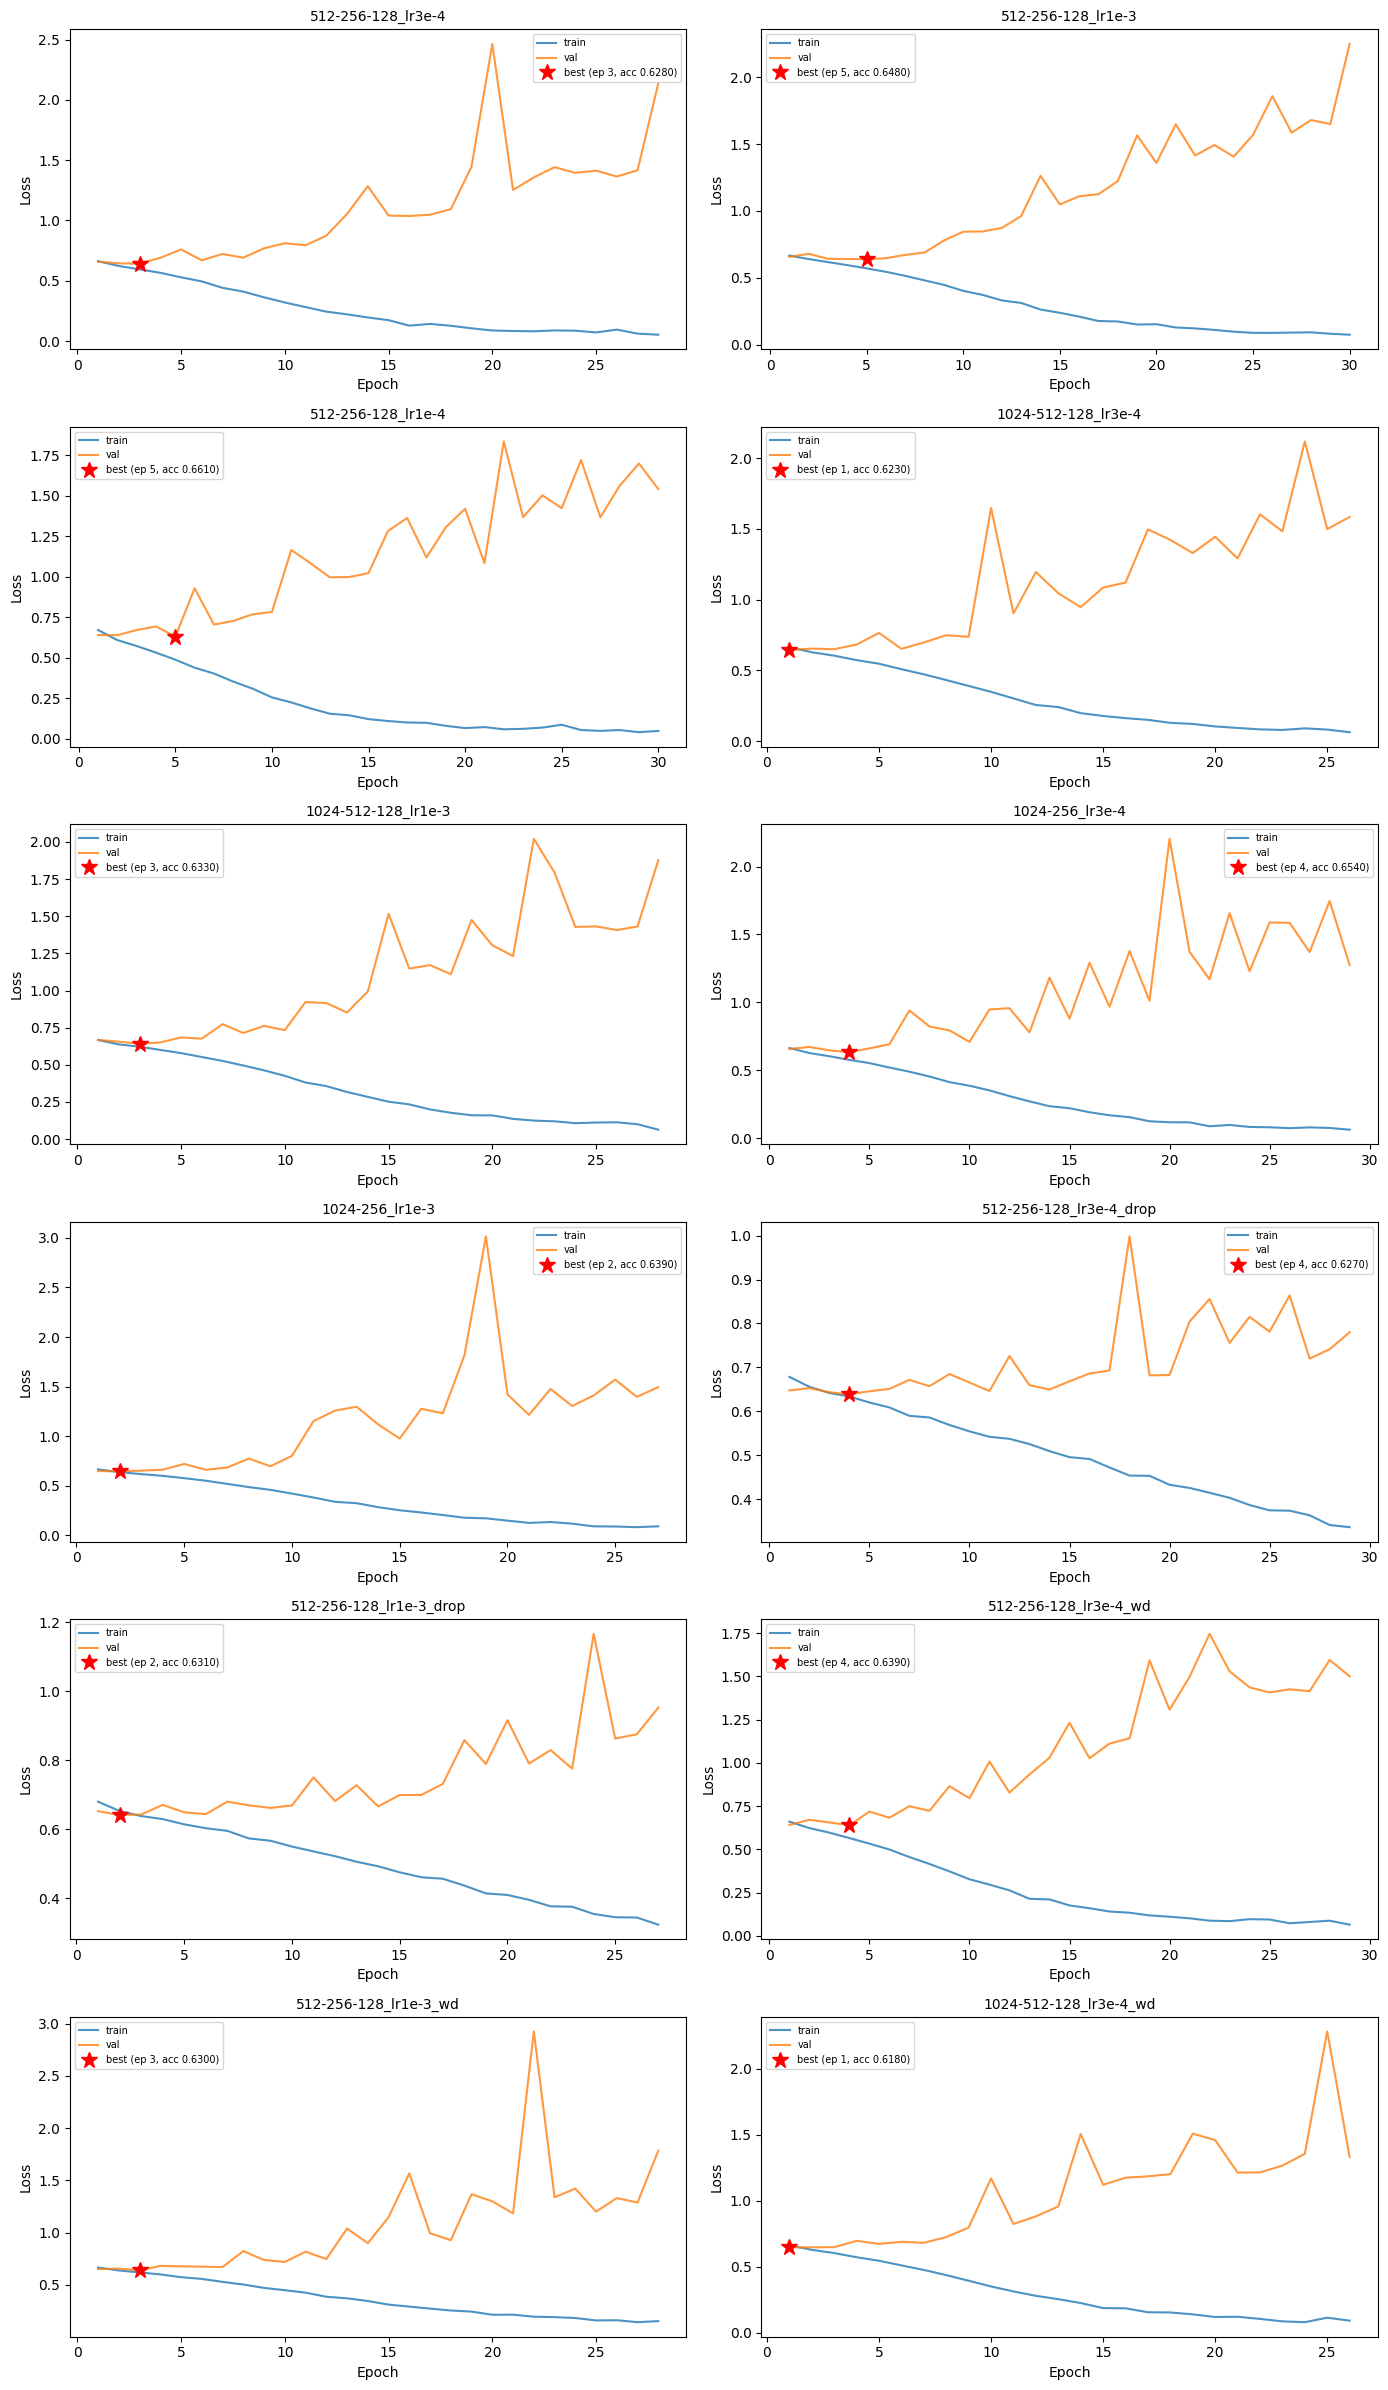

In [184]:
fig, axes = plt.subplots(6, 2, figsize=(14, 24))
axes = axes.flatten()

for idx, (name, res) in enumerate(cd_results.items()):
    ax = axes[idx]
    h = res["history"]
    ax.plot(range(1, len(h["train_losses"]) + 1), h["train_losses"], label="train", alpha=0.8)
    ax.plot(range(1, len(h["val_losses"]) + 1), h["val_losses"], label="val", alpha=0.8)
    if h["best_epoch"] is not None:
        ax.plot(h["best_epoch"], h["best_val_loss"], "*", color="red", markersize=12,
                label=f"best (ep {h['best_epoch']}, acc {h['best_val_acc']:.4f})")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [185]:
df_cd = pd.DataFrame({
    name: {
        "arch": "\u2192".join(map(str, r["h"])),
        "lr": r["lr"],
        "dropout": r["drop"],
        "weight_decay": r["wd"],
        "params": r["params"],
        "best_val_acc": f"{r['history']['best_val_acc']:.4f}",
        "test_acc": f"{r['test_acc']:.4f}",
        "test_loss": f"{r['test_loss']:.4f}",
        "epochs": len(r["history"]["train_losses"]),
    }
    for name, r in cd_results.items()
}).T.sort_values("test_acc", ascending=False)

df_cd

,arch,lr,dropout,weight_decay,params,best_val_acc,test_acc,test_loss,epochs
512-256-128_lr1e-4,512→256→128,0.0001,0.0,0.0,1739521,0.6610,0.6515,0.6481,30
512-256-128_lr1e-3,512→256→128,0.001,0.0,0.0,1739521,0.6480,0.6395,0.6618,30
1024-256_lr3e-4,1024→256,0.0003,0.0,0.0,3411969,0.6540,0.6385,0.6357,29
1024-512-128_lr1e-3,1024→512→128,0.001,0.0,0.0,3740673,0.6330,0.6375,0.6417,28
1024-256_lr1e-3,1024→256,0.001,0.0,0.0,3411969,0.6390,0.6360,0.6482,27
512-256-128_lr1e-3_drop,512→256→128,0.001,0.3,0.0,1739521,0.6310,0.6290,0.6446,27
512-256-128_lr3e-4_drop,512→256→128,0.0003,0.3,0.0,1739521,0.6270,0.6265,0.6449,29
512-256-128_lr3e-4,512→256→128,0.0003,0.0,0.0,1739521,0.6280,0.6230,0.6471,28
1024-512-128_lr3e-4,1024→512→128,0.0003,0.0,0.0,3740673,0.6230,0.6220,0.6464,26
1024-512-128_lr3e-4_wd,1024→512→128,0.0003,0.0,0.0001,3740673,0.6180,0.6220,0.6557,26


In [186]:
# Experiment: activation function comparison
# Fixed arch: 512->256->128 with BN, lr=3e-4, no dropout/wd

activations = {
    "Sigmoid": nn.Sigmoid,
    "Tanh": nn.Tanh,
    "ReLU": nn.ReLU,
}

def build_model_with_act(hidden_sizes, act_cls):
    layers = []
    in_dim = 32 * 32 * 3
    for h in hidden_sizes:
        layers.append(nn.Linear(in_dim, h))
        layers.append(nn.BatchNorm1d(h))
        layers.append(act_cls())
        in_dim = h
    layers.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*layers)

ACT_EPOCHS = 120
ACT_PATIENCE = 25
act_results = {}

for act_name, act_cls in activations.items():
    print(f"Training with {act_name} ...")
    model = build_model_with_act([512, 256, 128], act_cls)
    opt = torch.optim.Adam(model.parameters(), lr=3e-4)
    crit = nn.BCEWithLogitsLoss()
    model = train(model, train_loader_cd, crit, opt, ACT_EPOCHS, val_loader=val_loader_cd, patience=ACT_PATIENCE, silent=True)
    test_loss, test_acc = evaluate(model, test_loader_cd, crit)
    act_results[act_name] = {
        "test_acc": float(test_acc),
        "history": model._history,
    }
    print(f"  test_acc={float(test_acc):.4f}, epochs={len(model._history['train_losses'])}")

print("\nDone!")

Training with Sigmoid ...
  test_acc=0.6285, epochs=34
Training with Tanh ...
  test_acc=0.6080, epochs=27
Training with ReLU ...
  test_acc=0.6420, epochs=28

Done!


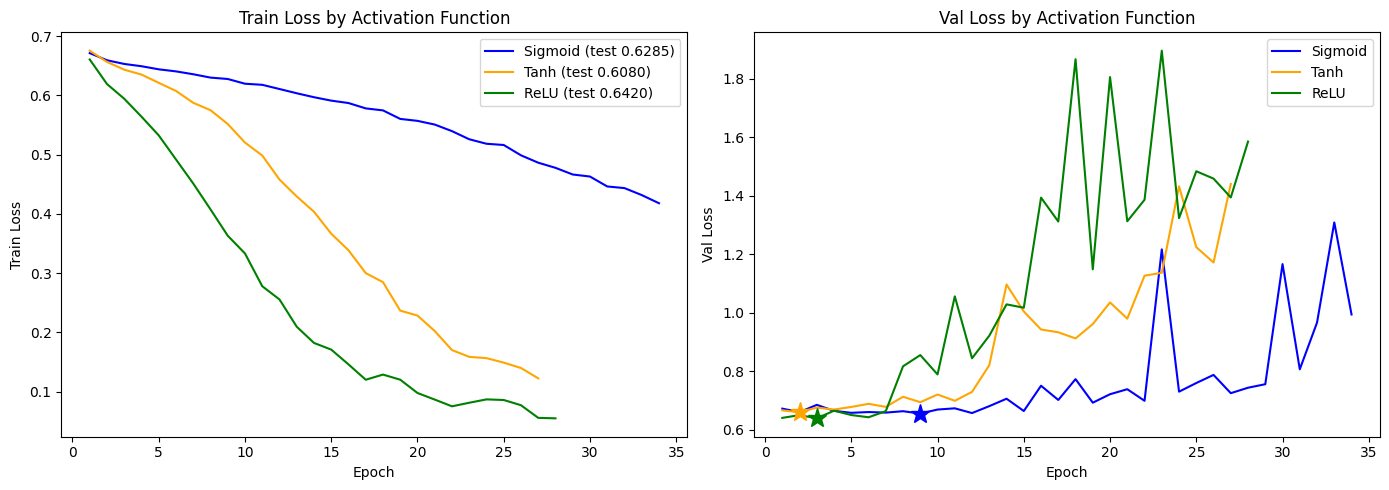

In [188]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {"Sigmoid": "blue", "Tanh": "orange", "ReLU": "green"}

for act_name, res in act_results.items():
    h = res["history"]
    epochs = range(1, len(h["train_losses"]) + 1)
    c = colors[act_name]
    ax1.plot(epochs, h["train_losses"], label=f"{act_name} (test {res['test_acc']:.4f})", color=c)
    ax2.plot(range(1, len(h["val_losses"]) + 1), h["val_losses"], label=f"{act_name}", color=c)
    if h["best_epoch"] is not None:
        ax2.plot(h["best_epoch"], h["best_val_loss"], "*", color=c, markersize=14, zorder=5)

ax1.set_xlabel("Epoch"); ax1.set_ylabel("Train Loss"); ax1.set_title("Train Loss by Activation Function")
ax1.legend()
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Val Loss"); ax2.set_title("Val Loss by Activation Function")
ax2.legend()
plt.tight_layout()
plt.show()

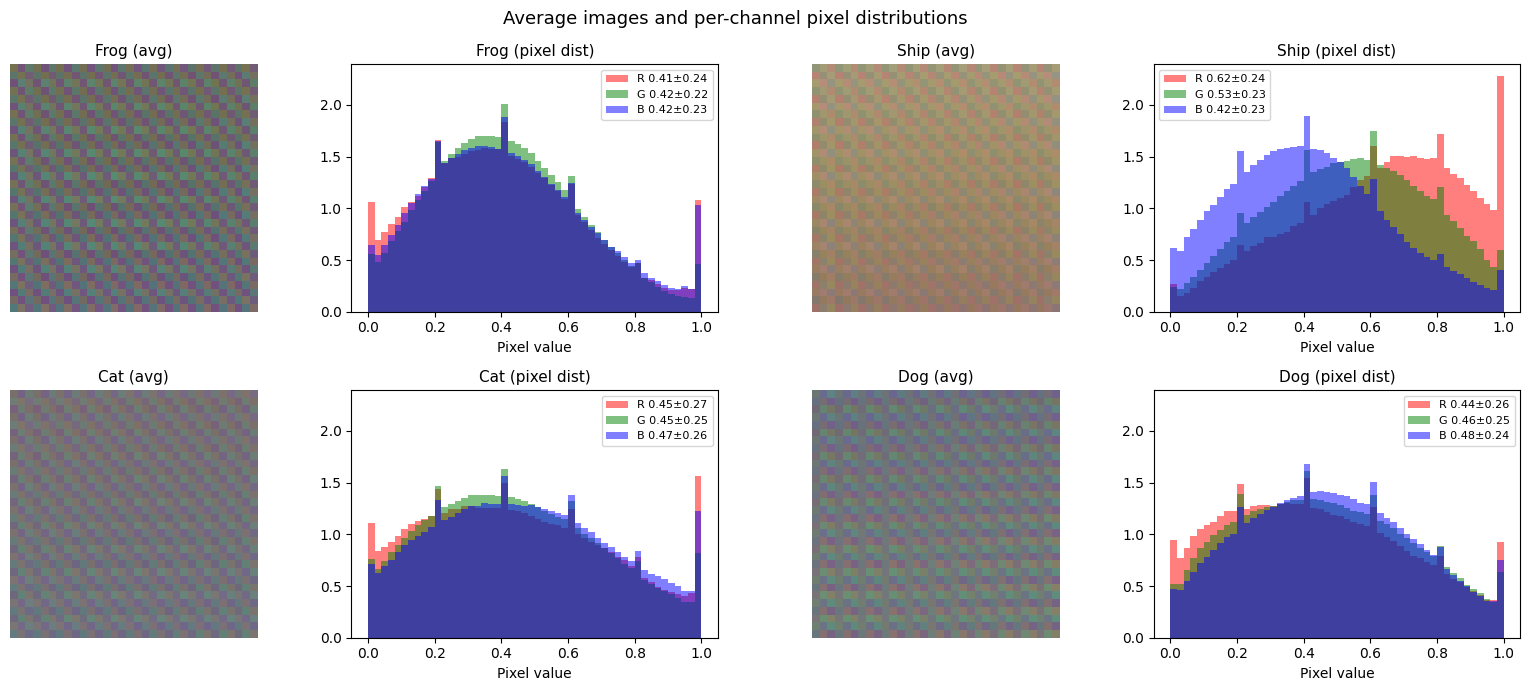

In [191]:
# Average images + per-channel distributions: frog vs ship, cat vs dog
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

datasets = [
    ("Frog", train_data_frog_ship[train_data_frog_ship["label"] == 0].drop(columns="label").values),
    ("Ship", train_data_frog_ship[train_data_frog_ship["label"] == 1].drop(columns="label").values),
    ("Cat", train_data_cat_dog[train_data_cat_dog["label"] == 0].drop(columns="label").values),
    ("Dog", train_data_cat_dog[train_data_cat_dog["label"] == 1].drop(columns="label").values),
]

colors_rgb = ["red", "green", "blue"]
hist_axes = []

for i, (name, pixels) in enumerate(datasets):
    row = 0 if i < 2 else 1
    col = i % 2

    # average image
    ax_img = axes[row, col * 2]
    avg_img = (pixels / 255.0).mean(axis=0).reshape(3, 32, 32).transpose(1, 2, 0)
    avg_img = np.clip(avg_img, 0, 1)
    ax_img.imshow(avg_img)
    ax_img.set_title(f"{name} (avg)", fontsize=11)
    ax_img.axis("off")

    # per-channel histogram
    ax_hist = axes[row, col * 2 + 1]
    hist_axes.append(ax_hist)
    channels = pixels.reshape(-1, 3, 32, 32)  # (N, 3, 32, 32)
    for ch, cname in enumerate(colors_rgb):
        ch_vals = channels[:, ch].flatten() / 255.0
        mu, std = ch_vals.mean(), ch_vals.std()
        ax_hist.hist(ch_vals, bins=50, alpha=0.5, color=cname, density=True,
                     label=f"{cname[0].upper()} {mu:.2f}±{std:.2f}")
    ax_hist.set_title(f"{name} (pixel dist)", fontsize=11)
    ax_hist.set_xlabel("Pixel value")
    ax_hist.legend(fontsize=8)

# shared y-axis across all histograms
y_max = max(ax.get_ylim()[1] for ax in hist_axes)
for ax in hist_axes:
    ax.set_ylim(0, y_max)

plt.suptitle("Average images and per-channel pixel distributions", fontsize=13)
plt.tight_layout()
plt.show()

# Experiments

- One layer 64 or 128 neurons: ~0.60 test acc.
- BatchNorm speeds up convergence a lot, model converges in couple of epochs.
- Dropout, weight decay, learning rate (1e-4 to 1e-3) had minimal effect.
- Best: **0.6515 test acc** on 512→256→128 with BN, Adam lr=1e-4.

------

## Q&A

**How large should the network be? Different from frog/ship?**

Doesn't matter much. 1 layer to 3 layers, with or without BN/dropout, all land in 0.60-0.65 range. Wider/deeper gets slightly better but nothing dramatic.

Very different from frog/ship where 1-layer MLP gets 0.94+. See the average images and pixel distributions above: frogs and ships have clearly different color profiles (green vs blue/gray), so raw pixel stats are enough. Cat and dog distributions are nearly identical, same grayish blob. The difference between them is spatial (ear shape, snout, fur texture) and flattening destroys that.

**How does behaviour change with hyperparameters?**

- BatchNorm: much faster convergence. Normalised layer outputs = more stable gradients.
- Dropout: no noticeable effect.
- Weight decay: no noticeable effect. Bottleneck is representation, not overfitting.
- LR: similar results across the range. Model exhausts learnable signal from flat pixels in 2-4 epochs, then just overfits.

**Interesting behaviour?**

The ~0.65 ceiling despite adding more params/compute. All models converge in 2-4 epochs. The model instantly learns whatever simple statistical signal exists in raw pixels and there's nothing more to extract. MLPs on flat pixels hit a hard ceiling here.

**Activation function and convergence speed?**

Same 512→256→128 BN arch, fixed hyperparams, three activations:
- ReLU: fastest, best test acc (0.642).
- Tanh: middle.
- Sigmoid: slowest.

Why: Sigmoid gradient is at most 0.25, vanishing gradients in deeper layers, slower learning. Tanh passes full gradient near 0 but kills it for |x| > ~2. ReLU has derivative 1 for any positive input, gradients flow freely.

Great! Now that we've tried to solve binary classification on CIFAR-10 data, we'll switch to the task of **multi-class classification**. But before that, let's talk about the `Dataset` class in PyTorch.


#### BatchNorm

Now let us talk about a new type of network layer: batch normalization. This is a layer that helps make training more stable and faster. In addition, a neural network with batch normalization layers can often learn a task better than the same network without batch normalization.

Let us consider a neural network with several layers. Notice that layers 2–3 of this network can be viewed as a separate, smaller neural network. The input data for this smaller network are the outputs of the first layer.

We already know that, for better neural network training, the input data should be normalized. Therefore, normalizing the outputs of each intermediate layer also helps the network train better. BatchNorm is exactly the layer that performs this kind of normalization.

There is also a second reason to normalize the outputs of intermediate layers. This is the internal covariate shift effect in neural networks. Originally, BatchNorm was introduced as a way to eliminate this effect.

network.svg

What is internal covariate shift? Consider a neural network with several layers. During training, all layers are trained jointly. Each layer of the network must adapt to the values produced by the previous layer. However, during training, the distribution of values produced by each layer changes. As a result, at every iteration of the algorithm, each hidden layer has to adapt to a new distribution of outputs from the previous layer. This makes the network train more slowly. Moreover, the weights can change quite significantly at each training iteration, which may provoke other problems, such as exploding gradients.

Normalizing the outputs of the network layers would help solve this problem.

So, how can we implement normalization of layer outputs? The simplest idea is to strictly normalize the output of each layer before passing it further through the network, just as we normalize the input data. For example, we could force the mean of all layer outputs to be 0 and the variance to be 1.

But why not give the neural network more freedom and allow it to determine for itself how exactly it is best to normalize the outputs of each layer?

That is precisely the idea behind BatchNorm. BatchNorm is a trainable layer that normalizes network outputs using trainable parameters.


**A BatchNorm layer is applied after a network layer and works as follows:**

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Basically, BatchNorm shifts mean of each neuron's output in the current batch to $\beta$, and variance to $\gamma$.

However, in this setup we will have a problem on inference, when we should be able to compute network's predictions on a single element. If we have only one element in a batch, we can't reliably estimate mean and variance to apply BatchNorm. The idea of a fix here is the following: during inference, we will use statistics for $\mu_B$ and $\sigma^2_B$ that we have computed during training.

For this reason, BatchNorm behaves differently during training and during inference. **During training, BatchNorm will do the following:**

Initialize running mean $\mu_r$ and $\sigma_B$ as zero. Set *momentum* hyperparameter to some constant between 0 and 1.

1. Compute the mean $\mu_B$ and variance $\sigma_B$ of the layer outputs over the batch. That is, suppose we have b outputs of the layer $\{x_i\}_{i=1}^b$, where $b$ is the batch size. Then:
    
$$\mu_B = \frac{\sum_{i=1}^b x_i}{b}$$

$$\sigma_B^2 = \frac{\sum_{i=1}^b (x_i - \mu_B)^2}{b}$$

Update the running mean and running variance:

$$\mu_r = (1-momentum)*\mu_r + momentum*\mu_B$$
$$\sigma_r = (1-momentum)*\sigma_r + momentum*\sigma_B$$

2.	Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_B}{\sigma_B}$$

3.	Compute the updated layer outputs as

$$y_i = \gamma \widehat{x_i} + \beta$$

where $\gamma$ and $\beta$ are trainable parameters.

Then we use $\mu_r$ and $\sigma_r$ during inference instead of batch-based statistics. So, **during inference BatchNorm does the following:**

1. Normalize the layer outputs:

$$\widehat{x_i} = \frac{x_i - \mu_r}{\sigma_r}$$

3.	Compute the updated layer outputs using trained $\gamma$ and $\beta$ as

$$y_i = \gamma \widehat{x_i} + \beta$$



## Task 2. Dataset class


In the task above we worked with CIFAR-10 data that we loaded into NumPy/Pandas structures and then passed directly to dataloaders. In PyTorch there is a class called `Dataset` which allows us to work with data in a more flexible way. It lets us define custom transformations of the data before passing it into the model.

In this task you will need to define a `Dataset` class based on our CIFAR-10 data. We will then use it for training a neural network for multi-class classification of the whole CIFAR-10 dataset.


In [198]:
import torch
from torch.utils.data import Dataset, DataLoader

### Task 2.1 Implement `CIFAR10Dataset` class.


Your task is to fill in the blanks in the cell below. Please note the following:
- The `__init__` method usually stores the input data in class variables. In our case the data comes into `__init__` as a pandas DataFrame. To access elements by index faster in the `__getitem__` method, convert the data to `np.array` format inside `__init__`.
- If you want to apply transformations to the data before feeding it to the neural network (normalization, reshaping, etc.), this is usually done in the `__getitem__` method. We would like to normalize our images, i.e. bring all pixel values to the interval `[0, 1]`. To do this, divide all pixel values by `255.`. Note that normalization should be done in the `__getitem__` method, **not** in `__init__`. This is checked by asserts later and by the testing system when the task is submitted.
- Below you will train a neural network to classify CIFAR images into 10 classes using this Dataset class. You might experiment with other transformations to help your network fit better. For example, you might want to resize images before feeding them into the model or convert images into grayscale — this would lower number of image pixels by 3! Pillow library (https://pypi.org/project/pillow/) can help you with that. You will need first to reshape your image vector into 32x32x3, convert to Pilow Image format, resize/do other transformations, concert back to Numpy and flatten the image back into the vector. You can think of other transformations that might help.


**Note**: here we start to use all labels in CIFAR dataset, as below we will build a neural network for multi-class classification (all 10 CIFAR classes). So you don't need to select data elements with certain labels anymore.

In [199]:
train_data.head()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,label
0,59,62,63,43,46,45,50,48,43,68,...,216,184,140,151,118,84,123,92,72,6
1,154,177,187,126,137,136,105,104,95,102,...,143,133,139,143,134,142,143,133,144,9
2,255,255,255,253,253,253,253,253,253,253,...,78,85,83,79,85,83,80,86,84,9
3,28,25,10,37,34,19,38,35,20,42,...,54,47,28,63,56,37,72,65,46,4
4,170,180,198,168,178,196,177,185,203,183,...,75,79,82,71,75,78,73,77,80,1


In [222]:
class CIFAR10Dataset(Dataset):
    def __init__(self, data):
        '''
        params:
            data (pd.DataFrame) — dataframe with flattened CIFAR-10 images and column `label`
        '''

        # load the data and
        # split it into features and target variable
        # and convert both to np.array
        # please do not change names of variables self.X and self.y,
        # it is important for the checks below to work correctly
        

        # features
        self.X = np.array(data.drop(columns='label'))
        # target variable
        self.y = np.array(data.label)

    def __len__(self):
        '''
        method that returns the number of objects in a dataset.
        This method is used by dataloader to generate batches of data
        '''
        return len(self.X)

    def __getitem__(self, idx):
        '''
        method that, given an index idx, returns the dataset object
        corresponding to the index.
        This method is used by dataloader to form batches of data
        params:
            idx: index of an element of the data
        '''

        # - get an object of data by index idx;
        # - normalize features (divide each pixel by 255.);
        # - convert features and target to tensor
        return torch.tensor(self.X[idx]) / 255, torch.tensor(self.y[idx], dtype=torch.long)


Now we can define training and testing datasets. We'll do this for multi-class classification using the whole CIFAR-10 dataframe.


In [223]:
cifar_train_dataset = CIFAR10Dataset(train_data)
cifar_test_dataset = CIFAR10Dataset(test_data)


The cell below checks that your Dataset class is implemented correctly


In [224]:
# check that types of self.X and self.y are np.array
assert type(cifar_train_dataset.X) == np.ndarray, "type of self.X in cifar_train_dataset is not np.array"
assert type(cifar_train_dataset.y) == np.ndarray, "type of self.y in cifar_train_dataset is not np.array"

# check that data is not normalized in __init__ method
assert max(cifar_train_dataset.X[0]) == 255, "data should not be normalized in __init__ method"

# check that data is normalized correctly in __getitem__ method
assert float(torch.max(cifar_train_dataset[0][0])) <= 1.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"
assert float(torch.min(cifar_train_dataset[0][0])) >= 0.0, "data is not normalized in __getitem__ method or it is normalized incorrectly"

# check that __getitem__ returns tensors
assert type(cifar_train_dataset[0][0]) == torch.Tensor, '__getitem__ returns other data type than tensor'
assert type(cifar_train_dataset[0][1]) == torch.Tensor, '__getitem__ returns other data type than tensor'


Great! After this we're ready to use our datasets. Now we can use `cifar_train_dataset` and `cifar_test_dataset` in `DataLoader`:


In [225]:
train_loader = torch.utils.data.DataLoader(cifar_train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(cifar_test_dataset, batch_size=64, shuffle=False)


Now we will train and test our network for multi-class classification using these new dataloaders.


## Task 3. Multi-class classification with NNs


### Neural network for multi-class classification


We already know how to build a neural network for the tasks of binary classification and regression. Let's learn what to do if we have a task of multi-class classification.



Consider a dataset for classification of crocodiles into 3 types:


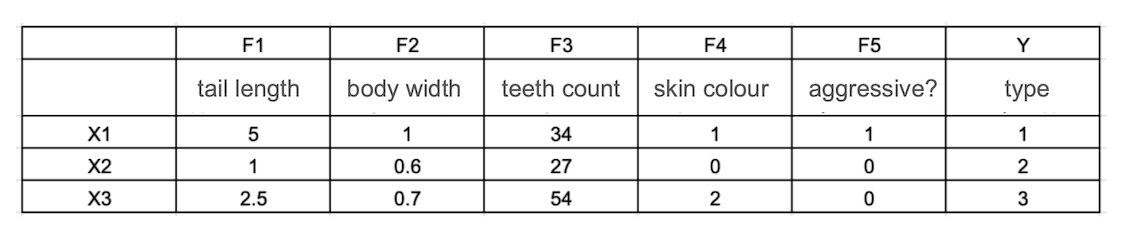


The simplest idea of neural network architecture for this task would be having one output neuron, which would output the class number of input object.


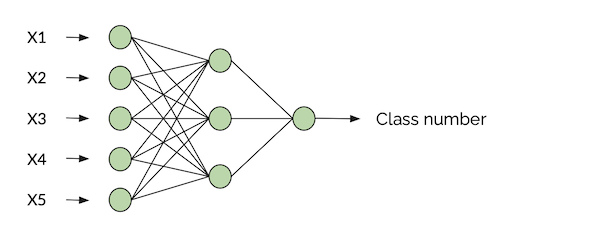


But there's a problem: how do we interpret outputs of such network? Let's say for some object our network outputs the value of 2.12. Does it mean that most likely our object belongs to the class 2? Or does the network think that the object is somewhere in between classes 1 and 3?


Okay, this was not the greatest idea. Let's now note, that a task of milti-class classification to $n$ classes can be wieved as $n$ binary classification tasks:
- does element belong to class 1?
- does element belong to class 2?
- ...
- does element belong to class n?

We can then make our neural network have n output neurons with Sigmoid activation function, and each output neuron will solve a corresponding binary classification tasks. So in our case with crocodile data it will look like that:


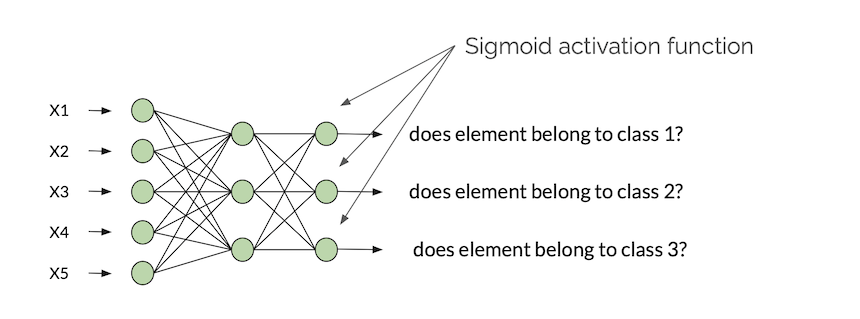


Such a network structure is suitable for the task of multi-label classification, where each input object can belong to arbitrary number of classes, i.e. where events "input object X belongs to class i" are independent. In the case of multi-class classification, these events are not independent, as each object can only belong to one class. So we would like decisions of neuron of the last layer to be agreed in some way.


The idea that comes to mind is the following: we would like neurons of the last layer to output a probability distribution over the classes. This means that the output of $i^{th}$ neuron will represent a probability that the input object belongs to the class $i$.

We also know the true distribution for each object, which is represented as one-hot vector. So as a loss function we could use some similarity measure between the true and predicted distributions.


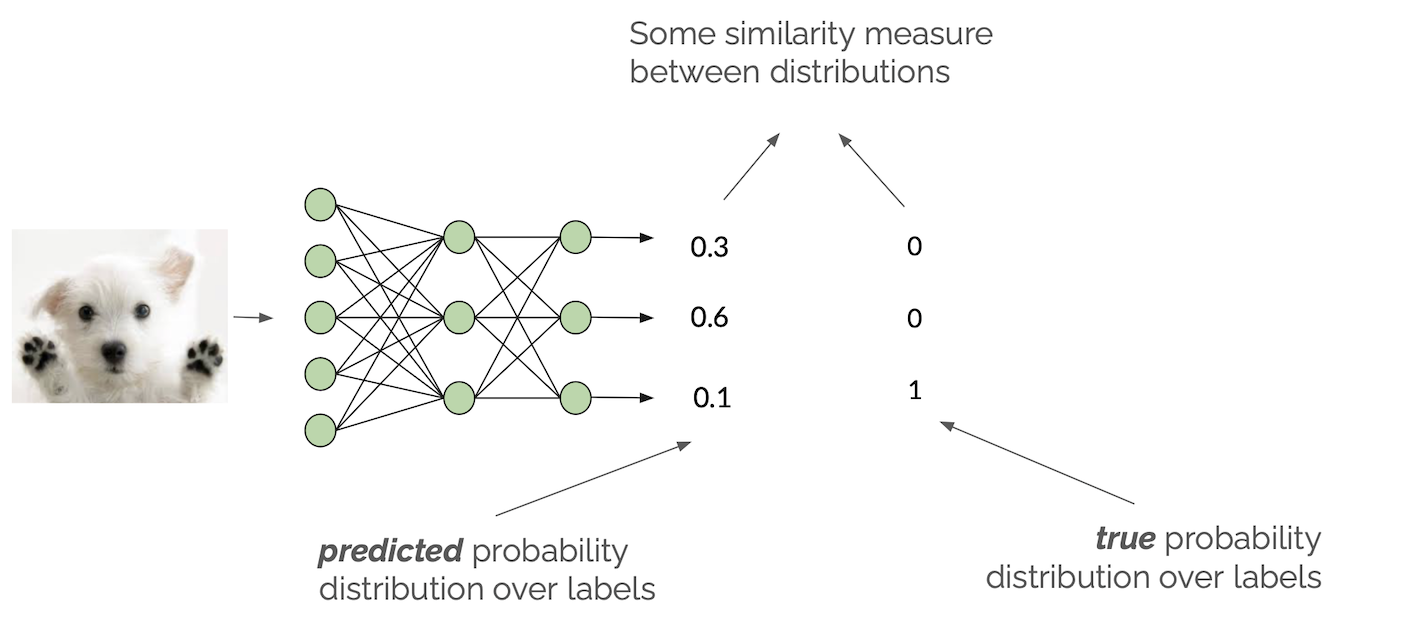


So we need to somehow convert the logits (outputs of the last linear layer) into the probability distribution. Let's do it using SoftMax activation function:

$$(p_1, p_2, p_3) = SoftMax(\widehat{p_1}, \widehat{p_2}, \widehat{p_3}) = \left( \frac{e^{\widehat{p_1}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_2}}}{\sum e^{\widehat{p_i}}}, \frac{e^{\widehat{p_3}}}{\sum e^{\widehat{p_i}}} \right)$$

We can see that SoftMax does indeed convert logits into probability distribution, as the sum of all elements becomes 1, and value of each element is in $[0, 1]$.

And as a similarity measure between the output distribution and true distribution we will use [cross-entropy](https://en.wikipedia.org/wiki/Cross-entropy), which is a measure of similarity of two probability distrubutions from information theory.

$$CE(y, p) = - \sum y_i log(p_i)$$

LogLoss is a binary version of cross-entropy.





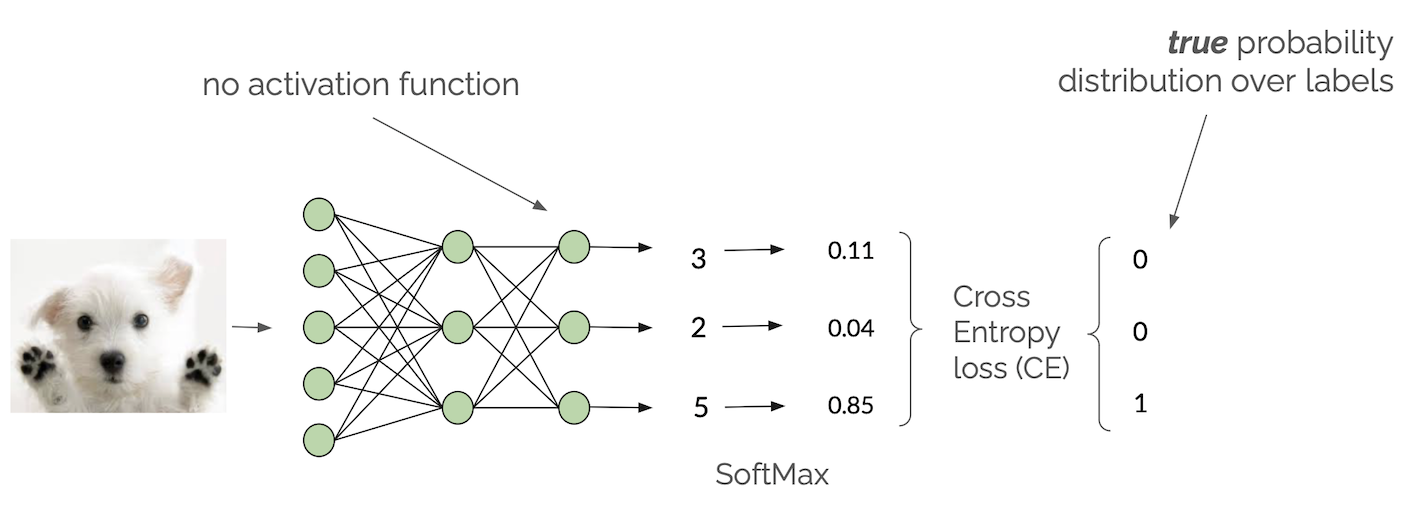


Let's also say a couple of words about why using SoftMax, as there are many ways to convert logits into probability distribution.

First, here's log function inside the formula of cross-entropy. If we pass logits $\widehat{p_i}$ through exponential function before feeding them into cross-entropy, we will end up $log(p_i)$ having the same magnitude as $\widehat{p_i}$. So this will encourage a neural network to output logits which have the same magnitude as $y_i$.

Second, SoftMax is a short for "Soft Maximum", and it has this name because it rebalances the values so that the maximum value becomes more pronounced, close to 1, while all other values get closer to zero.

Here's an example of how SoftMax changes logits:


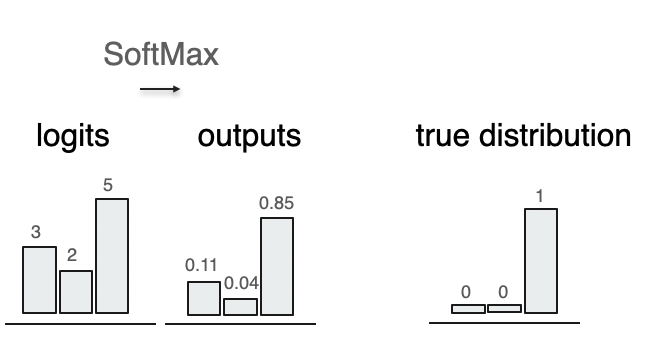


So it is called "Soft Maximum", as it acts almost like argmaximum function, but softer, not putting all the probability weight into one place.


To sum up, if you are building neural network for $n$-class classification task with $n>2$, then:
- last layer of the network should have $n$ neurons
- activation of the last layer of the network should be SoftMax (https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html)
- loss function is cross-entropy (https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)

Note, however, that PyTorch implementation of CE (torch.nn.CrossEntropyLoss) expects to have logits as input, not probabilities after SoftMax. It applies SoftMax inside loss function. This is done due to efficiency of computing gradients. So if you use torch.nn.CrossEntropyLoss as loss function, there should be no activation function in the last layer of the network.


### Task 3.1 Write a neural network for multi-class classification


Define a neural network that should solve a multi-class classification task with 10 classes on CIFAR-10. Think about the following:
- How many input and output neurons should your network have?
- What activation function should the last layer have?


In [226]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self, input_dim: int, linear_blocks: list):
        super(Net, self).__init__()

        # define layers and activation function that your model will have
        # YOUR CODE HERE
        layers = []
        in_dim = input_dim
        for h in linear_blocks:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            in_dim = h
        layers.append(nn.Linear(in_dim, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):

        # define a flow of input through your layers
        # YOUR CODE HERE
        x = self.net(x)
        return x


And create a network:


In [230]:
net = Net(input_dim=32*32*3, linear_blocks=[128])

### Task 3.2 Define a train function


You can copy it from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?


In [231]:
import tqdm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
import copy


def train(model, train_loader, criterion, optimizer, num_epoch, val_loader=None, patience=None, silent=False):
    train_losses = []
    val_losses = []
    val_accs = []

    # early stopping state
    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_state = None
    wait = 0
    best_epoch = None

    for epoch in range(num_epoch):
        model.train()
        avg_loss = 0.0
        for i, (x, y) in enumerate(train_loader, 1):
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            avg_loss += (loss.item() - avg_loss) / i

        train_losses.append(avg_loss)

        # validation
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for j, (xv, yv) in enumerate(val_loader, 1):
                    pred_v = model(xv)
                    loss_v = criterion(pred_v, yv)
                    val_loss += (loss_v.item() - val_loss) / j
                    pred_labels = pred_v.argmax(dim=1)
                    correct += (pred_labels == yv).sum().item()
                    total += yv.size(0)
            val_losses.append(val_loss)
            val_accs.append(correct / total)

            # early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_val_acc = val_accs[-1]
                best_epoch = epoch + 1
                best_state = copy.deepcopy(model.state_dict())
                wait = 0
            else:
                wait += 1
                if patience is not None and wait >= patience:
                    if not silent:
                        print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
                    break

        if not silent:
            clear_output(wait=True)
            plt.figure()
            plt.plot(range(1, len(train_losses) + 1), train_losses, label="train")
            if val_losses:
                plt.plot(range(1, len(val_losses) + 1), val_losses, label="val")
                if best_epoch is not None:
                    plt.plot(best_epoch, best_val_loss, "*", color="red", markersize=14, zorder=5,
                             label=f"best val (ep {best_epoch}, acc {best_val_acc:.4f})")
            plt.xlabel("Epoch")
            plt.ylabel("Avg Loss")
            plt.title("Training Loss")
            plt.legend()
            plt.show()

    # restore best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)

    # attach history to model
    model._history = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
    }

    return model


And let's define loss function, optimizer, dataloader and train our network. Use the full `cifar_train_dataset` here.


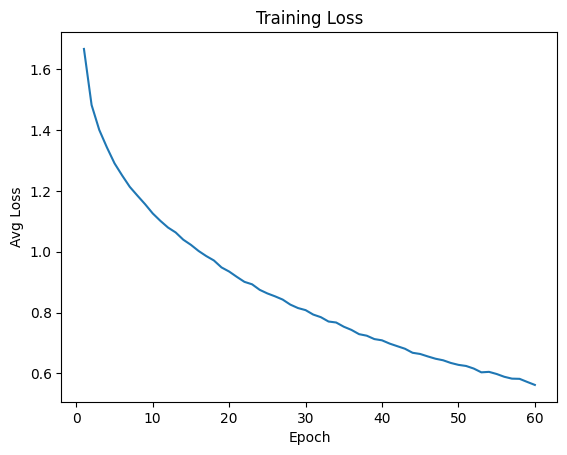

In [232]:
# loss function
criterion = nn.CrossEntropyLoss() # YOUR CODE HERE — define a loss function (cross-entropy)
# optimizer
optimizer = torch.optim.Adam(net.parameters()) # YOUR CODE HERE — define an optimizer and pass params of neural network to it
# dataloader
train_loader = torch.utils.data.DataLoader(cifar_train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(cifar_test_dataset, batch_size=64, shuffle=False)
# run training
NN = train(net, train_loader, criterion, optimizer, 60)


### Task 3.3. Write a code for model evaluation


Again, you can borrow the code from the task above. Does the train function need any modification given that now we're solving a multi-class classification task?


In [ ]:
def evaluate(model, loader, criterion):
    '''
    args:
        model - our neural network model
        loader — structure which yields batches of test data
        criterion - loss function from `torch.nn` module
    '''

    # arrays for storing loss values, network predictions and true values
    losses = []
    y_pred_list = []
    y_true_list = []

    for X_batch, y_batch in loader:

        # this disables gradient computations to save time and memory
        # we don't need gradients on test data
        with torch.no_grad():
            # getting our model's predictions on current batch
            y_pred = # YOUR CODE HERE

            # calculate loss function
            loss = # YOUR CODE HERE
            losses.append(loss.item())


        # convert outputs of your network into class number
        y_pred = # YOUR CODE HERE

        # save for accuracy calculation
        y_pred_list.extend(y_pred)
        y_true_list.extend(y_batch.tolist())

    # calculate accuracy score based on y_pred_list and y_true_list
    accuracy = # YOUR CODE HERE

    return np.mean(losses), accuracy


### Task 3.4 Train the neural network.


Here, again, your task is to improve the network so that it can achieve higher accuracy. Try to achieve **>0.53 accuracy** on the CIFAR-10 test part, but in general your goal is to improve as much as possible.

You are free to build any neural network architecture you want and use any hyperparameters for training. Here are some tips:
- Start with 1-3 hidden layers having, for example, 128-512 neurons each
- Think about how many neurons your input and output layers should have
- What activation function do you need to use in the last layer? **Be careful here:** check the documentation of the loss function that use are using: does it require logits or probabilities?
- Play with number of layers, numbers of neurons, and different activation functions
- Try different training hyperparameters: learning rate, number of epochs, optimizer type, batch size
- As we've discussed above, play with data preprocessing in the Dataset class.

While you're doing experimenting, describe your findings. Try to answer the following questions:
- How large should the neural network be to solve the task successfully? There are two dimensions to neural network size: **depth** and **width**.
- How does the behaviour of the model change when you change different hyperparameters?
- What interesting behaviour have you observed? What was beneficial and what did not influence the model?
- How does the number of epochs needed to achieve the same value of loss function change when you change the activation function? Fix the network architecture and all training hyperparameters and train the neural network with three different activation functions in hidden layers (Sigmoid, Tanh, ReLU). Plot how training loss evolves during training in these three cases.


In [ ]:
# YOUR CODE HERE

That's it for the tasks in this notebook!
